In [23]:
import sys
sys.path.append('../')

import itertools
import sympy as sp
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from finite_groups import FiniteGroup
from induced_rep_solver import InducedRepSolver
from symchar.symchar import character_table

def RELU(x): return sp.Max(0, x)
def TANH(x): return sp.tanh(x)
def SIGMOID(x): return 1 / (1 + sp.exp(-x))
def LINEAR(x): return x
def SQUARE(x): return x**2
def RELU_TANH(x): return RELU(x) + TANH(x)

# Utils

In [24]:
def build_Cn(n):
    elements = list(range(n))
    def mult(a,b):
        return (a+b) % n

    return FiniteGroup(elements, mult)


def build_Sk(k):
    elements = list(itertools.permutations(range(k)))
    def mult(a,b):
        return tuple(a[i] for i in b)

    return FiniteGroup(elements, mult)


def build_product(G1,G2):

    elements = [(g,h) for g in G1.elements for h in G2.elements]
    def mult(x,y):

        g1,h1 = x
        g2,h2 = y

        return (
            G1.mult_func(g1,g2),
            G2.mult_func(h1,h2)
        )

    return FiniteGroup(elements, mult)


# def build_H(k):

#     perms = list(itertools.permutations(range(k-1)))

#     H = []

#     for p in perms:

#         perm = list(range(k))

#         for i in range(k-1):
#             perm[i] = p[i]

#         H.append((0,tuple(perm)))

#     return H

def build_H(k):
    """
    H = {e} inside C_n × S_k
    """
    identity_perm = tuple(range(k))
    return [(0, identity_perm)]

## Characters

In [25]:
def generate_partitions(n):
    def generate(n, max_part, current, result):
        if n == 0:
            result.append(tuple(current))
            return
        for i in range(min(max_part, n), 0, -1):
            generate(n - i, i, current + [i], result)

    result = []
    generate(n, n, [], result)
    return result

def Sk_character_table(k):
    char_table = np.array(character_table(k), dtype=object).T
    partitions = generate_partitions(k)
    labels = [''.join(map(str,p)) for p in partitions]

    partition_map = {
        tuple(sorted(p, reverse=True)): i
        for i,p in enumerate(partitions)
    }

    return char_table, labels, partition_map


def Cn_character_table(n, labels=None):
    table = []

    for g in range(n):
        row = [sp.exp(2*sp.pi*sp.I*g*m/n) for m in range(n)]
        table.append(row)

    if labels is None:
        labels = [rf"\chi_{j}" for j in range(n)]

    return np.array(table, dtype=object), labels

def cycle_type(perm):
    k = len(perm)
    seen = [False]*k
    parts = []

    for i in range(k):
        if not seen[i]:
            j=i
            length=0
            while not seen[j]:
                seen[j]=True
                j=perm[j]
                length+=1
            parts.append(length)

    return tuple(sorted(parts, reverse=True))


def direct_prod_character_table(G,
                                Cn_table, Cn_labels,
                                Sk_table, Sk_labels,
                                Sk_partition_map):

    labels = [
        rf"${c}\otimes{s}$"
        for c in Cn_labels
        for s in Sk_labels
    ]

    class_char_dict = {}

    for cls in G.classes:

        g, sigma = cls.representative

        cn_row = Cn_table[g]

        part = cycle_type(sigma)

        if part not in Sk_partition_map:
            raise ValueError(
                f"Cycle type {part} not found in partition map."
            )

        sk_row = Sk_table[Sk_partition_map[part]]

        row = []

        for chi in cn_row:
            for psi in sk_row:
                row.append(sp.simplify(chi*psi))

        class_char_dict[cls.representative] = row

    return class_char_dict, labels

In [60]:
n = 5
k = 4

def periodic_relu(x):
    u = sp.Abs(x)
    return sp.floor(u / 2) + sp.Min(sp.Mod(u, 2), 1)

activation_fn = RELU

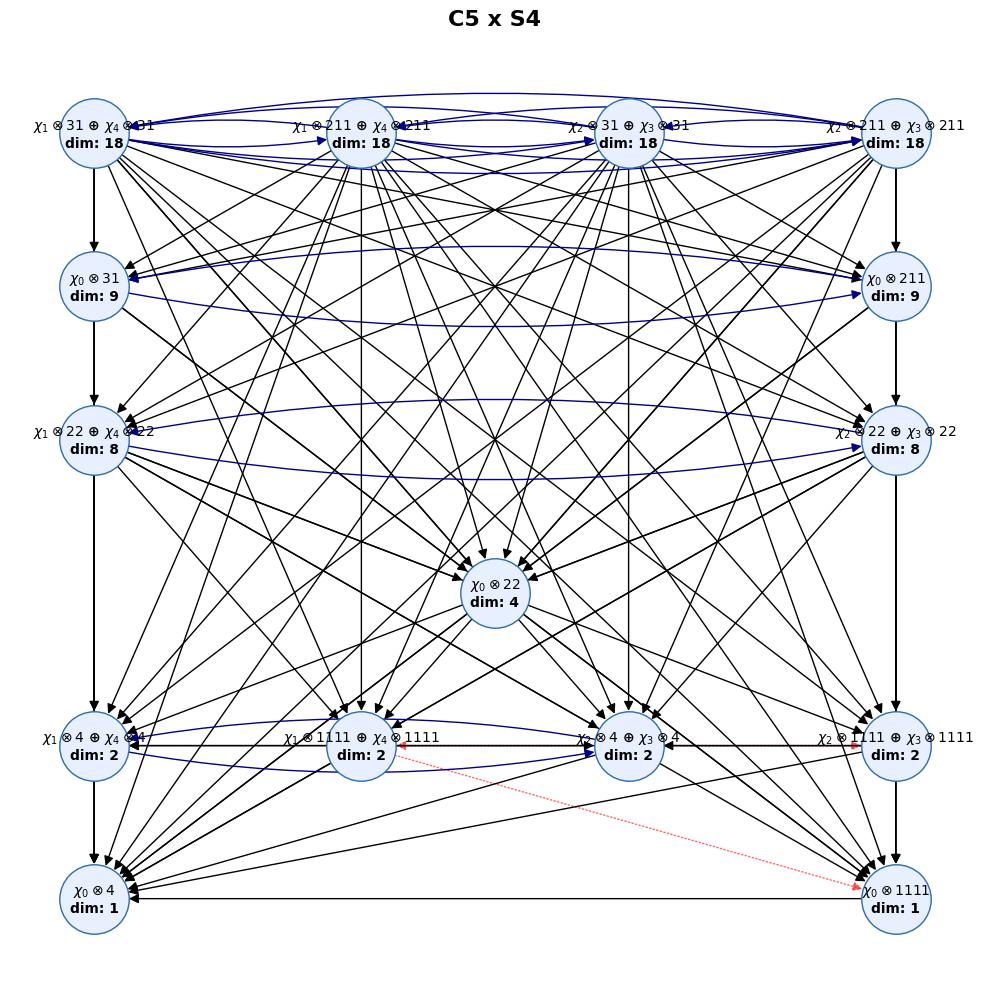

In [61]:
Cn = build_Cn(n)
Sk = build_Sk(k)

G = build_product(Cn,Sk)
H = build_H(k)

solver = InducedRepSolver(G)
solver.set_subgroup(H)

Sk_char_table, Sk_labels, Sk_partition_map = Sk_character_table(k)
Cn_char_table, Cn_labels = Cn_character_table(n)
char_table, labels = direct_prod_character_table(G, Cn_char_table, Cn_labels, Sk_char_table, Sk_labels, Sk_partition_map)

solver.load_character_table(char_table, labels)
solver.compute_projectors(refine=False)

# graph = solver.build_interaction_graph(activation_fn=activation_fn)
graph = solver.build_isotypic_graph(activation_fn=activation_fn)
solver.visualise_interaction_graph(graph, group_name=f"C{n} x S{k}", node_size=2500, show_self_loops=False)

In [57]:
col_ranges = {}
col_labels = []

start = 0
blocks = []

for label, Qblock in solver.Qblocks.items():
    r, c = Qblock.shape
    if r > 1:                      
        blocks.append(Qblock)

        end = start + c
        col_ranges[label] = (start, end)
        col_labels.extend([label] * c)
        start = end


Q = sp.Matrix(np.hstack(blocks))
Q_inv = Q.inv()


print(col_ranges)
Q_inv * (Q).applyfunc(activation_fn)

{'$\\chi_0\\otimes4$': (0, 1), '$\\chi_0\\otimes31$': (1, 10), '$\\chi_0\\otimes22$': (10, 14), '$\\chi_0\\otimes211$': (14, 23), '$\\chi_0\\otimes1111$': (23, 24), '$\\chi_1\\otimes4$ ⊕ $\\chi_3\\otimes4$': (24, 26), '$\\chi_1\\otimes31$ ⊕ $\\chi_3\\otimes31$': (26, 44), '$\\chi_1\\otimes22$ ⊕ $\\chi_3\\otimes22$': (44, 52), '$\\chi_1\\otimes211$ ⊕ $\\chi_3\\otimes211$': (52, 70), '$\\chi_1\\otimes1111$ ⊕ $\\chi_3\\otimes1111$': (70, 72), '$\\chi_2\\otimes4$': (72, 73), '$\\chi_2\\otimes31$': (73, 82), '$\\chi_2\\otimes22$': (82, 86), '$\\chi_2\\otimes211$': (86, 95), '$\\chi_2\\otimes1111$': (95, 96)}


Matrix([
[1,  9/8, 9/8, 9/8,  9/8,  9/8, 9/8,  9/8,  9/8,  9/8, 2/3,  2/3,  2/3, 2/3,  9/8, 9/8, 9/8,  9/8,  9/8, 9/8,  9/8,  9/8,  9/8, 1/2, 1/2,  1/2,  9/8, 9/8, 9/8,  9/8,  9/8, 9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8, 2/3,  2/3,  2/3, 2/3,  2/3,  2/3,  2/3,  2/3,  9/8, 9/8, 9/8,  9/8,  9/8, 9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8,  9/8, 1/2,  1/2, 1/2,  9/8, 9/8, 9/8,  9/8,  9/8, 9/8,  9/8,  9/8,  9/8, 2/3,  2/3,  2/3, 2/3,  9/8, 9/8, 9/8,  9/8,  9/8, 9/8,  9/8,  9/8,  9/8, 1/2],
[0,  5/8,   0,   0,    0,    0,   0,    0,    0,    0,   0,    0,    0,   0,  1/8,   0,   0,    0,    0,   0,    0,    0,    0,   0,   0,    0,  1/8,   0,   0,    0,    0,   0,    0,    0,    0,  1/8,    0,    0,    0,    0,    0,    0,    0,    0,   0,    0,    0,   0,    0,    0,    0,    0,  1/8,   0,   0,    0,    0,   0,    0,    0,    0,  1/8,    0,    0,    0,    0,    0,    0,    0,    0,   0,    0,   0,  1/8,   0,   0,    0,    0,  

In [58]:
def is_zero_block(block):
    return all(entry == 0 for entry in block)

def build_block_adjacency(Psi, col_ranges):
    """
    Returns labels and a 0/1 adjacency matrix A where
    A[i][j] = 1 means block j -> block i is nonzero.
    """
    labels = list(col_ranges.keys())
    m = len(labels)
    A = [[0]*m for _ in range(m)]

    for i, label_to in enumerate(labels):
        r0, r1 = col_ranges[label_to]

        for j, label_from in enumerate(labels):
            c0, c1 = col_ranges[label_from]

            block = Psi[r0:r1, c0:c1]
            if not is_zero_block(block):
                A[i][j] = 1

    return labels, A

from collections import deque

def is_block_graph_triangular(labels, A):
    """
    Check whether the block interaction graph is triangularisable,
    i.e. whether it is acyclic after ignoring self-loops.
    """
    n = len(labels)

    # remove self-loops
    B = A - np.eye(n, dtype=int) 

    # indegree for graph j -> i when B[i][j] = 1
    indeg = [0]*n
    out = [[] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if B[i][j]:
                out[j].append(i)
                indeg[i] += 1

    q = deque([v for v in range(n) if indeg[v] == 0])
    topo = []

    while q:
        v = q.popleft()
        topo.append(v)
        for w in out[v]:
            indeg[w] -= 1
            if indeg[w] == 0:
                q.append(w)

    is_dag = (len(topo) == n)
    topo_labels = [labels[i] for i in topo] if is_dag else None

    return is_dag, topo_labels

Psi = Q_inv * (Q).applyfunc(activation_fn)
labels, A = build_block_adjacency(Psi, col_ranges)
is_dag, topo_labels = is_block_graph_triangular(labels, A)

print("Triangularisable?", is_dag)    

Triangularisable? False


In [59]:
list(topo_labels)

TypeError: 'NoneType' object is not iterable

In [42]:
def run(n,k, activation=RELU, Cn_labels=None):

    Cn = build_Cn(n)
    Sk = build_Sk(k)

    G = build_product(Cn,Sk)
    H = build_H(k)

    solver = InducedRepSolver(G)
    solver.set_subgroup(H)

    Sk_char_table, Sk_labels, Sk_partition_map = Sk_character_table(k)
    Cn_char_table, Cn_labels = Cn_character_table(n, Cn_labels)
    char_table, labels = direct_prod_character_table(G, Cn_char_table, Cn_labels, Sk_char_table, Sk_labels, Sk_partition_map)

    solver.load_character_table(char_table, labels)
    solver.compute_projectors(refine=False)

    graph = solver.build_isotypic_graph(activation_fn=activation)

    return graph, solver

In [43]:
graphs = {}
n = 4
activation_fn = RELU

for i in range(1, n+1):
    for j in range(1, n+1):
        print(f"Computing C{i+1} x S{j+1}")
        graphs[(i, j)] = run(i, j, activation=activation_fn)

def create_svg_grid(graphs, n, filename="grid.svg"):

    fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            graph, solver = graphs[(i+1, j+1)]
            solver.visualise_interaction_grid(graph, ax=ax, group_name=f"C{i+1} x S{j+1}")


    plt.tight_layout()
    fig.savefig(filename, format="svg")
    plt.close(fig)


create_svg_grid(graphs, n=n, filename=f"outputs/Regular_Cn_Sk_n={n}_{activation_fn.__name__}.svg")

Computing C2 x S2
Computing C2 x S3
Computing C2 x S4
Computing C2 x S5
Computing C3 x S2
Computing C3 x S3
Computing C3 x S4
Computing C3 x S5
Computing C4 x S2
Computing C4 x S3
Computing C4 x S4
Computing C4 x S5
Computing C5 x S2
Computing C5 x S3
Computing C5 x S4
Computing C5 x S5
